<a href="https://colab.research.google.com/github/sohamsabane/-FeatureEngineering-/blob/main/Soham_Sabane_GenerativeAILabAssignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Neural Network Implementation from Scratch

## Generative AI Lab

**Name:** Soham Sabane  
**PRN Number:** 202401110070  
**Batch:** A3  
**Department:** CSE AIML  
**Course:** Generative AI Lab  
**Date of Submission:** 15/08/2026

## 1. Objective

The objective of this experiment is to implement a simple feedforward neural network
from scratch in Python without using any in-built deep learning libraries.

The implementation focuses on the following fundamental components:

- Forward propagation
- Backpropagation
- Loss calculation
- Gradient descent
- Weight and bias updates
- Model training
- Prediction and evaluation

## 2. Problem Definition

The objective is to build a simple feedforward neural network that can classify
Iris flowers into two different classes.

For this experiment, the following two Iris classes are selected:

- Iris Setosa → Class 0
- Iris Versicolor → Class 1

The model uses four input features:

1. Sepal Length
2. Sepal Width
3. Petal Length
4. Petal Width

This is a binary classification problem.

The neural network will be implemented from scratch using NumPy.
No TensorFlow, PyTorch, Keras, or other deep learning frameworks are used
for implementing the neural network.

## 3. Dataset Description

The Iris dataset is used for this experiment.

The original Iris dataset contains 150 samples belonging to three different
flower classes.

For this experiment, only two classes are selected:

- Iris Setosa
- Iris Versicolor

Therefore, the final dataset contains 100 samples.

Each sample has four input features:

| Feature | Description |
|---|---|
| Sepal Length | Length of the sepal |
| Sepal Width | Width of the sepal |
| Petal Length | Length of the petal |
| Petal Width | Width of the petal |

The target values are:

- 0 → Iris Setosa
- 1 → Iris Versicolor

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [3]:
# Load Iris dataset
iris = load_iris()

X = iris.data
y = iris.target

print("Dataset shape:", X.shape)
print("Target shape:", y.shape)

Dataset shape: (150, 4)
Target shape: (150,)


In [4]:
# Select only Setosa (0) and Versicolor (1)
mask = y < 2

X = X[mask]
y = y[mask]

print("Input shape:", X.shape)
print("Target shape:", y.shape)
print("Classes:", np.unique(y))

Input shape: (100, 4)
Target shape: (100,)
Classes: [0 1]


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 80
Testing samples: 20


In [6]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Training data standardized successfully.")

Training data standardized successfully.


## Neural Network Architecture

The neural network consists of three layers:

Input Layer:
- 4 neurons

Hidden Layer:
- 8 neurons
- Sigmoid activation

Output Layer:
- 1 neuron
- Sigmoid activation

Architecture:

4 Input Neurons
       ↓
8 Hidden Neurons
       ↓
1 Output Neuron

The output represents the probability of the sample belonging to Class 1.

## Sigmoid Activation Function

The sigmoid function converts a value into a range between 0 and 1.

It is defined as:

σ(x) = 1 / (1 + e^(-x))

The derivative of sigmoid is:

σ'(x) = σ(x)(1 - σ(x))

The sigmoid function is used in both the hidden and output layers.

In [7]:
def sigmoid(x):
    return 1 / (1 + np.exp(-np.clip(x, -500, 500)))


def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)

In [8]:
np.random.seed(42)

input_neurons = 4
hidden_neurons = 8
output_neurons = 1

# Weights
W1 = np.random.randn(input_neurons, hidden_neurons) * 0.01
W2 = np.random.randn(hidden_neurons, output_neurons) * 0.01

# Biases
b1 = np.zeros((1, hidden_neurons))
b2 = np.zeros((1, output_neurons))

print("W1 shape:", W1.shape)
print("W2 shape:", W2.shape)
print("b1 shape:", b1.shape)
print("b2 shape:", b2.shape)

W1 shape: (4, 8)
W2 shape: (8, 1)
b1 shape: (1, 8)
b2 shape: (1, 1)


## Forward Propagation

During forward propagation, the input moves through the network.

First hidden-layer weighted sum:

Z1 = XW1 + b1

Hidden-layer activation:

A1 = sigmoid(Z1)

Output-layer weighted sum:

Z2 = A1W2 + b2

Final prediction:

A2 = sigmoid(Z2)

The output A2 represents the predicted probability.

In [9]:
def forward_pass(X, W1, b1, W2, b2):

    # Hidden layer
    Z1 = np.dot(X, W1) + b1
    A1 = sigmoid(Z1)

    # Output layer
    Z2 = np.dot(A1, W2) + b2
    A2 = sigmoid(Z2)

    return Z1, A1, Z2, A2

## Forward Propagation

During forward propagation, the input moves through the network.

First hidden-layer weighted sum:

Z1 = XW1 + b1

Hidden-layer activation:

A1 = sigmoid(Z1)

Output-layer weighted sum:

Z2 = A1W2 + b2

Final prediction:

A2 = sigmoid(Z2)

The output A2 represents the predicted probability.

In [10]:
def binary_cross_entropy(y_true, y_pred):

    epsilon = 1e-8

    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)

    loss = -np.mean(
        y_true * np.log(y_pred) +
        (1 - y_true) * np.log(1 - y_pred)
    )

    return loss

## Backpropagation

Backpropagation calculates how much each weight contributes to the error.

The gradients are calculated starting from the output layer and moving backward
towards the input layer.

The gradients are then used by gradient descent to update the weights and biases.

The main steps are:

1. Calculate output error.
2. Calculate gradients for W2 and b2.
3. Propagate error to hidden layer.
4. Calculate gradients for W1 and b1.
5. Update weights and biases.

In [11]:
def backward_pass(X, y, Z1, A1, Z2, A2, W2):

    m = X.shape[0]

    # Output layer error
    dZ2 = A2 - y.reshape(-1, 1)

    # Gradients for second layer
    dW2 = np.dot(A1.T, dZ2) / m
    db2 = np.sum(dZ2, axis=0, keepdims=True) / m

    # Hidden layer error
    dA1 = np.dot(dZ2, W2.T)
    dZ1 = dA1 * sigmoid_derivative(Z1)

    # Gradients for first layer
    dW1 = np.dot(X.T, dZ1) / m
    db1 = np.sum(dZ1, axis=0, keepdims=True) / m

    return dW1, db1, dW2, db2

In [12]:
def update_parameters(W1, b1, W2, b2, dW1, db1, dW2, db2, learning_rate):

    W1 = W1 - learning_rate * dW1
    b1 = b1 - learning_rate * db1

    W2 = W2 - learning_rate * dW2
    b2 = b2 - learning_rate * db2

    return W1, b1, W2, b2

In [13]:
epochs = 5000
learning_rate = 0.1

loss_history = []

for epoch in range(epochs):

    # Forward propagation
    Z1, A1, Z2, A2 = forward_pass(
        X_train, W1, b1, W2, b2
    )

    # Calculate loss
    loss = binary_cross_entropy(
        y_train.reshape(-1, 1),
        A2
    )

    loss_history.append(loss)

    # Backpropagation
    dW1, db1, dW2, db2 = backward_pass(
        X_train,
        y_train,
        Z1,
        A1,
        Z2,
        A2,
        W2
    )

    # Update parameters
    W1, b1, W2, b2 = update_parameters(
        W1,
        b1,
        W2,
        b2,
        dW1,
        db1,
        dW2,
        db2,
        learning_rate
    )

    if epoch % 500 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.6f}")

Epoch 0, Loss: 0.693267
Epoch 500, Loss: 0.042922
Epoch 1000, Loss: 0.012104
Epoch 1500, Loss: 0.006769
Epoch 2000, Loss: 0.004640
Epoch 2500, Loss: 0.003509
Epoch 3000, Loss: 0.002812
Epoch 3500, Loss: 0.002340
Epoch 4000, Loss: 0.002001
Epoch 4500, Loss: 0.001746


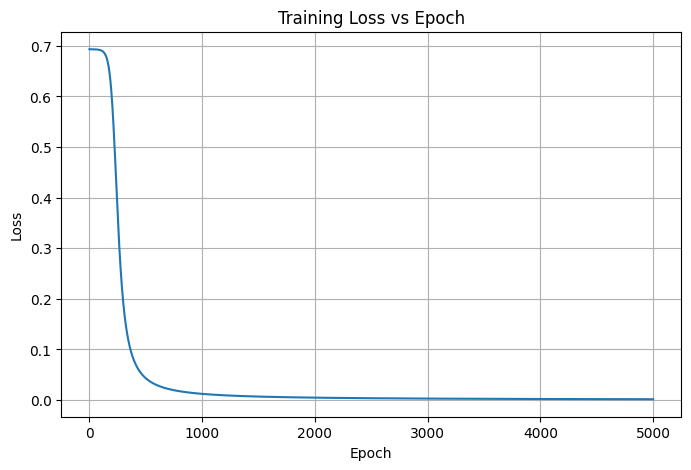

In [14]:
plt.figure(figsize=(8, 5))

plt.plot(loss_history)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss vs Epoch")

plt.grid(True)
plt.show()

In [15]:
def predict(X):

    _, _, _, output = forward_pass(
        X, W1, b1, W2, b2
    )

    return (output >= 0.5).astype(int)

In [16]:
y_pred = predict(X_test)

print("Predicted values:")
print(y_pred.flatten())

print("\nActual values:")
print(y_test)

Predicted values:
[1 1 1 1 0 0 0 1 0 0 0 1 0 0 0 1 1 0 1 1]

Actual values:
[1 1 1 1 0 0 0 1 0 0 0 1 0 0 0 1 1 0 1 1]


In [17]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Test Accuracy: {accuracy * 100:.2f}%")

Test Accuracy: 100.00%


In [18]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[10  0]
 [ 0 10]]


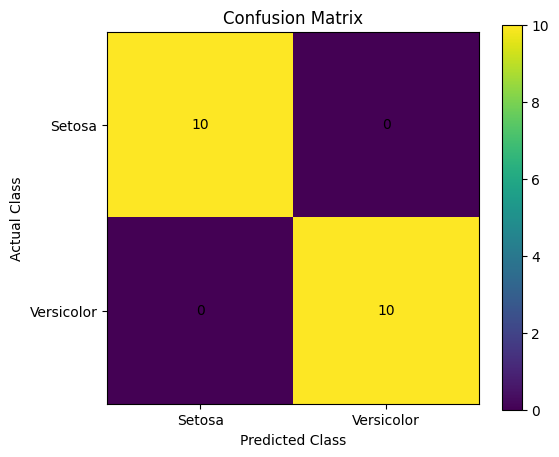

In [19]:
plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.xticks([0, 1], ["Setosa", "Versicolor"])
plt.yticks([0, 1], ["Setosa", "Versicolor"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j],
                 ha="center",
                 va="center")

plt.colorbar()
plt.show()

In [20]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["Setosa", "Versicolor"]
))

              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       1.00      1.00      1.00        10

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



## Results

The neural network was successfully implemented from scratch using NumPy.

The model was trained using:

- Input neurons: 4
- Hidden neurons: 8
- Output neurons: 1
- Hidden activation: Sigmoid
- Output activation: Sigmoid
- Loss function: Binary Cross-Entropy
- Optimization algorithm: Gradient Descent
- Number of epochs: 5000
- Learning rate: 0.1

The training loss decreased during training, indicating that the model learned
the relationship between the input features and target classes.

The final test accuracy is obtained from the model evaluation performed above.

## Declaration

I, Soham Sabane, confirm that the work submitted in this assignment is my
own and has been completed following academic integrity guidelines.

The code is uploaded on my GitHub repository.

**GitHub Repository Link:** [Insert GitHub Link]

**Signature:** [Soham M Sabane]